<img src="https://raw.githubusercontent.com/harmonize-tools/socio4health/main/docs/source/_static/image.png" alt="image info" height="100" width="100"/>


# Hands-on with socio4health: effects of hydrometeorologigcal hazards and urbanization on dengue risk in Brazil 



**Run the tutorial via free cloud platforms:**  [![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/harmonize-tools/socio4health/HEAD?urlpath=%2Fdoc%2Ftree%2Fdocs%2Fsource%2Fnotebooks%2Fexample_brazil.ipynb) <a target="_blank" href="https://colab.research.google.com/github/harmonize-tools/socio4health/blob/main/docs/source/notebooks/example_brazil.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

This notebook provides a real-world example of how to use **socio4health** to **retrieve**, **harmonize** and **analyze** **socioeconomic and demographic**  variables, such as the level of urbanization and access to water supply in Brazil, to recreate the dataset used in the publication *Combined effects of hydrometeorological hazards and urbanisation on dengue risk in Brazil: a spatiotemporal modelling study* by Lowe et al., published in *The Lancet Planetary Health* in 2021 ([DOI](https://doi.org/10.1016/S2542-5196(20)30292-8)). The study evaluated how the association between hydrometeorological events and **dengue** risk varies with these variables. This tutorial assumes an **intermediate** or **advanced** understanding of **Python** and data manipulation.

## Setting up the environment

To run this notebook, you need to have the following prerequisites:

- **Python 3.10+**

Additionally, you need to install the `socio4health` and `pandas` package, which can be done using ``pip``:



In [ ]:
!pip install socio4health pandas -q

## Import Libraries

To perform the data extraction, the `socio4health` library provides the `Extractor` class for data extraction, and the `Harmonizer` class for data harmonization of the retrieved date. `pandas` will be used for data manipulation. Additionally, we will use some utility functions from the `socio4health.utils.harmonizer_utils` module to **standardize** and **translate** the dictionary.


In [3]:
import re
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from socio4health import Extractor
from socio4health.harmonizer import Harmonizer
from socio4health.utils import harmonizer_utils, extractor_utils

## 1. Load and standardize the dictionary
To harmonize the data, provide a dictionary that describes the variables in the dataset. The study retrieved data from the 2010 census, from Instituto Brasileiro de Geografia e Estatística (**IBGE**). The dictionary for the census data can be found [here](https://ftp.ibge.gov.br/Censos/Censo_Demografico_2010/Resultados_Gerais_da_Amostra/Microdados/Documentacao.zip). Follow the steps in the tutorial ["How to Create a Raw Dictionary for Data Harmonization"](https://harmonize-tools.github.io/socio4health/dictionary.html) to create a raw dictionary in Excel format.

This dictionary must be standardized and translated to English. The `socio4health.utils.harmonizer_utils` module provides utility functions to perform these tasks. Additionally, the `socio4health.utils.extractor_utils` module provides utility functions to parse fixed-width file (FWF) dictionaries, which is the format used in the **IBGE** census data.


In [4]:
raw_dic = pd.read_excel("raw_dictionary_br_2010.xlsx")
dic=harmonizer_utils.s4h_standardize_dict(raw_dic)
colnames, colspecs =extractor_utils.s4h_parse_fwf_dict(dic)


This is how the standardized dictionary looks:

In [5]:
dic

,description,value,initial_position,final_position,size,dec,type,possible_answers,question,variable_name
0,NaN,1.0; 2.0; 9.0,107.0,107.0,1.0,NaN,C,apenas um morador; mais de um morador; ignorado,a responsabilidade pelo domicílio é de:,V0402
1,NaN,1.0; 2.0; 3.0,90.0,90.0,1.0,NaN,C,"sim, em pelo menos um cômodo; sim, só na propr...","abastecimento de água, canalização:",V0209
2,NaN,1.0; 2.0; 3.0; 4.0; 5.0; 6.0; 7.0; 8.0; 9.0; 10.0,88.0,89.0,2.0,NaN,C,rede geral de distribuição; poço ou nascente n...,"abastecimento de água, forma:",V0208
3,NaN,1.0; 2.0; 3.0,144.0,144.0,1.0,NaN,C,adequada; semi-adequada; inadequada,adequação da moradia,V6210
4,NaN,1.0; 2.0,104.0,104.0,1.0,NaN,C,sim; não,alguma pessoa que morava com você(s) estava mo...,V0301
...,...,...,...,...,...,...,...,...,...,...
71,NaN,1.0; 2.0,95.0,95.0,1.0,NaN,C,sim; não,"televisão, existência:",V0214
72,NaN,11.0; 12.0; 13.0; 14.0; 15.0; 51.0; 52.0; 53.0...,56.0,57.0,2.0,NaN,C\n,casa; casa de vila ou em condomínio; apartamen...,tipo de espécie:,V4002
73,NaN,11.0; 12.0; 13.0; 14.0; 15.0; 16.0; 17.0; 21.0...,1.0,2.0,2.0,NaN,A,rondônia; acre; amazonas; roraima; pará; amapá...,unidade da federação:,V0001
74,NaN,NaN,59.0,64.0,6.0,NaN,N,NaN,valor do aluguel (em reais),V2011


The classification model used in this tutorial is a **BERT model** fine-tuned for the task of classifying survey questions into categories. You can use your own model by providing the path to the model in the `MODEL_PATH` parameter of the `harmonizer_utils.s4h_classify_rows` function.

In [6]:
dic = harmonizer_utils.s4h_translate_column(dic, "question", language="en")
dic = harmonizer_utils.s4h_translate_column(dic, "description", language="en")
dic = harmonizer_utils.s4h_translate_column(dic, "possible_answers", language="en")
dic = harmonizer_utils.s4h_classify_rows(dic, "question_en", "description_en", "possible_answers_en",
                                        new_column_name="category",
                                        MODEL_PATH="dirreno/harmonize_bert_finetuned_classifier")
dic

2026-10-06 14:38:04,909 - INFO - HTTP Request: HEAD https://huggingface.co/Helsinki-NLP/opus-mt-ROMANCE-en/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-10-06 14:38:04,924 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Helsinki-NLP/opus-mt-ROMANCE-en/e9ca9975e3972afd80732f08ce01d3a1339f47f8/config.json "HTTP/1.1 200 OK"
2026-10-06 14:38:05,024 - INFO - HTTP Request: HEAD https://huggingface.co/Helsinki-NLP/opus-mt-ROMANCE-en/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-10-06 14:38:05,025 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-10-06 14:38:05,039 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Helsinki-NLP/opus-mt-ROMANCE-en/e9ca9975e3972afd80732f08ce01d3a1339f47f8/tokenizer_config.json "HTTP/1.1 200 OK"
2026-10-06 14:38:05,138 - INFO - HTTP Request: GET https://huggingfa

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

2026-10-06 14:38:06,746 - INFO - HTTP Request: GET https://huggingface.co/api/models/Helsinki-NLP/opus-mt-ROMANCE-en/commits/refs%2Fpr%2F6 "HTTP/1.1 200 OK"
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
2026-10-06 14:38:07,316 - INFO - HTTP Request: HEAD https://huggingface.co/Helsinki-NLP/opus-mt-ROMANCE-en/resolve/refs%2Fpr%2F6/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-10-06 14:38:07,335 - INFO - HTTP Request: HEAD https://huggingface.co/Helsinki-NLP/opus-mt-ROMANCE-

question translated
description translated
possible_answers translated


2026-10-06 14:38:25,253 - INFO - HTTP Request: HEAD https://huggingface.co/dirreno/harmonize_bert_finetuned_classifier/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-10-06 14:38:25,268 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/dirreno/harmonize_bert_finetuned_classifier/04a378f831c207100f9f6bf0f367a114c62d9c8a/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

2026-10-06 14:38:25,562 - INFO - HTTP Request: GET https://huggingface.co/api/models/dirreno/harmonize_bert_finetuned_classifier/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-10-06 14:38:25,677 - INFO - HTTP Request: GET https://huggingface.co/api/models/dirreno/harmonize_bert_finetuned_classifier/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"


,description,value,initial_position,final_position,size,dec,type,possible_answers,question,variable_name,question_en,description_en,possible_answers_en,category
0,NaN,1.0; 2.0; 9.0,107.0,107.0,1.0,NaN,C,apenas um morador; mais de um morador; ignorado,a responsabilidade pelo domicílio é de:,V0402,the responsibility for the household is:,NaN,only one resident; more than one resident; ign...,Housing
1,NaN,1.0; 2.0; 3.0,90.0,90.0,1.0,NaN,C,"sim, em pelo menos um cômodo; sim, só na propr...","abastecimento de água, canalização:",V0209,"water supply, pipeline:",NaN,"yes, in at least one room; yes, only in proper...",Housing
2,NaN,1.0; 2.0; 3.0; 4.0; 5.0; 6.0; 7.0; 8.0; 9.0; 10.0,88.0,89.0,2.0,NaN,C,rede geral de distribuição; poço ou nascente n...,"abastecimento de água, forma:",V0208,"water supply, shape:",NaN,general distribution network; well or spring o...,Business
3,NaN,1.0; 2.0; 3.0,144.0,144.0,1.0,NaN,C,adequada; semi-adequada; inadequada,adequação da moradia,V6210,adequacy of housing,NaN,adequate; semi-adequate; inadequate,Housing
4,NaN,1.0; 2.0,104.0,104.0,1.0,NaN,C,sim; não,alguma pessoa que morava com você(s) estava mo...,V0301,someone who lived with you was living in anoth...,NaN,Yes; no,Business
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,NaN,1.0; 2.0,95.0,95.0,1.0,NaN,C,sim; não,"televisão, existência:",V0214,"television, existence:",NaN,Yes; no,Identification
72,NaN,11.0; 12.0; 13.0; 14.0; 15.0; 51.0; 52.0; 53.0...,56.0,57.0,2.0,NaN,C\n,casa; casa de vila ou em condomínio; apartamen...,tipo de espécie:,V4002,type of species:,NaN,house; town house or condominium; apartment; d...,Housing
73,NaN,11.0; 12.0; 13.0; 14.0; 15.0; 16.0; 17.0; 21.0...,1.0,2.0,2.0,NaN,A,rondônia; acre; amazonas; roraima; pará; amapá...,unidade da federação:,V0001,Federation unit:,NaN,rondônia; acre; amazon; roraima; pará; amapá; ...,Business
74,NaN,NaN,59.0,64.0,6.0,NaN,N,NaN,valor do aluguel (em reais),V2011,value of rent (in reals),NaN,NaN,Business


## 2. Extract data from Brazil Census 2010

To extract data, use the `Extractor` class from the `socio4health` library. As in the publication, extract the Brazil Census 2010 dataset from the Brazilian Institute of Geography and Statistics (**IBGE**) website or from a local copy. The dataset is available [here](https://www.ibge.gov.br/estatisticas/sociais/saude/9662-censo-demografico-2010.html?=&t=microdados).

The `Extractor` class requires the following parameters:
- `input_path`: The `URL` or local path to the data source.
- `down_ext`: A list of file extensions to download. This can include `.txt`,`.zip`, etc.
- `output_path`: The local path where the extracted data will be saved.
- `key_words`: A list of keywords to filter the files to be downloaded. In this case, a regular expression is used to select only the files with a `.zip` extension that contain uppercase letters in their names.
- `depth`: The depth of the directory structure to traverse when downloading files. A depth of `0` means only the files in the specified directory will be downloaded.
- `is_fwf`: A boolean indicating whether the files are in fixed-width format (FWF). In this case, the files are in FWF format, so this parameter is set to `True`.
- `colnames`: A list of column names for the FWF files, extracted from the standardized dictionary.
- `colspecs`: A list of tuples indicating the start and end positions of each column in the FWF files, extracted from the standardized dictionary.


In [7]:
bra_online_extractor = Extractor(input_path="https://ftp.ibge.gov.br/Censos/Censo_Demografico_2010/Resultados_Gerais_da_Amostra/Microdados/",
                                 down_ext=['.txt','.zip'],
                                 output_path="IBGE_2010_",
                                 key_words=[r"^[A-Z0-9_]+\.zip$"],
                                 depth=0, is_fwf=True, colnames=colnames, colspecs=colspecs)
bra_Censo_2010 = bra_online_extractor.s4h_extract()

2026-10-06 14:38:28,420 - INFO - ----------------------
2026-10-06 14:38:28,420 - INFO - Starting data extraction...
2026-10-06 14:38:28,420 - INFO - Extracting data in online mode...
2026-10-06 14:38:28,421 - INFO - Scraping URL: https://ftp.ibge.gov.br/Censos/Censo_Demografico_2010/Resultados_Gerais_da_Amostra/Microdados/ with depth 0
2026-10-06 14:38:31,523 - INFO - Spider completed successfully for URL: https://ftp.ibge.gov.br/Censos/Censo_Demografico_2010/Resultados_Gerais_da_Amostra/Microdados/
2026-10-06 14:38:31,525 - INFO - Downloading files to: IBGE_2010_
2026-10-06 14:40:37,104 - INFO - Processing (depth 0): AC.zip
2026-10-06 14:40:37,223 - INFO - Extracted: b65dc3a4_AC_Amostra_Domicilios_12.txt
2026-10-06 14:40:37,225 - INFO - Extracted: b65dc3a4_AC_Amostra_Emigracao_12.txt
2026-10-06 14:40:37,227 - INFO - Extracted: b65dc3a4_AC_Amostra_Mortalidade_12.txt
2026-10-06 14:40:37,244 - INFO - Extracted: b65dc3a4_AC_Amostra_Pessoas_12.txt
2026-10-06 14:40:37,245 - INFO - Processi

## 3. Harmonize the data

Use the Harmonizer class from the **socio4health** library to harmonize the data. First, set the similarity threshold to `0.9`, meaning that only variables with a similarity score of `0.9` or higher will be considered for harmonization. Next, use the `s4h_vertical_merge` method to merge the dataframes vertically.

In [8]:
har = Harmonizer()
har.similarity_threshold = 0.9
dfs = har.s4h_vertical_merge(bra_Censo_2010)

Grouping DataFrames: 100%|█| 112/112 [00:00<00:00, 137.4
Merging groups: 100%|█████| 1/1 [00:00<00:00,  1.88it/s]


After merging the dataframes, set the dictionary and the categories of interest. In this case, we are interested in the `"Business"` category. Then, use the `s4h_data_selector` method to filter the dataframes based on the dictionary, categories, and a key column (in this case `'V0001'`, which represents the state code). The `s4h_data_selector` method returns a list of **filtered dataframes**.

In [9]:
har.dict_df = dic
har.categories = ["Business"]
har.key_col = 'V0001'
filtered_ddfs = har.s4h_data_selector(dfs)

2026-10-06 14:46:06,702 - WARNING - key_col or key_val not defined, row-wise size will not be reduced


In [10]:
len(filtered_ddfs)

1

In [11]:
filtered_ddfs[0].compute()

,V0001,V0208,V0301,V0222,V0701,V0211,V0212,M0201,M0202,M0203,...,M2011,V0202,V0221,V0401,V6531,V6532,V6530,V6529,V1005,V2011
0,12,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,201080
1,12,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,8,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,200480
2,12,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,200780
3,12,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,8,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,200880
4,12,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,201080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133867,17,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,<NA>,...,1,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,042042
133868,17,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,<NA>,...,2,3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,046046
133869,17,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,<NA>,...,1,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,037037
133870,17,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,0,...,1,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,018018


Finally, we can perform some **analysis** on the harmonized data. In this case, we will calculate the total population by state (`V0001`) using the variable `V0401`, which represents the total population in each census tract. We will then create a horizontal bar plot to visualize the population distribution across states using `matplotlib`.

In [12]:
ddf = filtered_ddfs[0][["V0001", "V0401"]]

ddf = ddf.assign(
    V0001 = ddf["V0001"].astype("category"),
    V0401 = dd.to_numeric(ddf["V0401"], errors="coerce").astype("float64").fillna(0.0)
).categorize(columns=["V0001"])

pop = ddf.groupby("V0001")["V0401"].sum(split_out=8).compute()

In [13]:
pop = pop[pop>0]
row = dic.loc[dic["variable_name"]=="V0001", ["value","possible_answers"]].iloc[0]

vals = [s for s in re.split(r"\s*;\s*", str(row["value"]).strip(" ;")) if s]
labs = [s for s in re.split(r"\s*;\s*", str(row["possible_answers"]).strip(" ;")) if s]

idx = pop.index
if pd.api.types.is_integer_dtype(idx):
    keys = [int(float(v)) for v in vals]
elif pd.api.types.is_float_dtype(idx):
    keys = [float(v) for v in vals]
else:
    keys = [str(int(float(v))) for v in vals]

if len(keys) != len(labs):
    raise ValueError(f"Misalignment: {len(keys)} codes vs {len(labs)} names")
code2name = dict(zip(keys, labs))

pop_named = pop.rename(index=code2name)


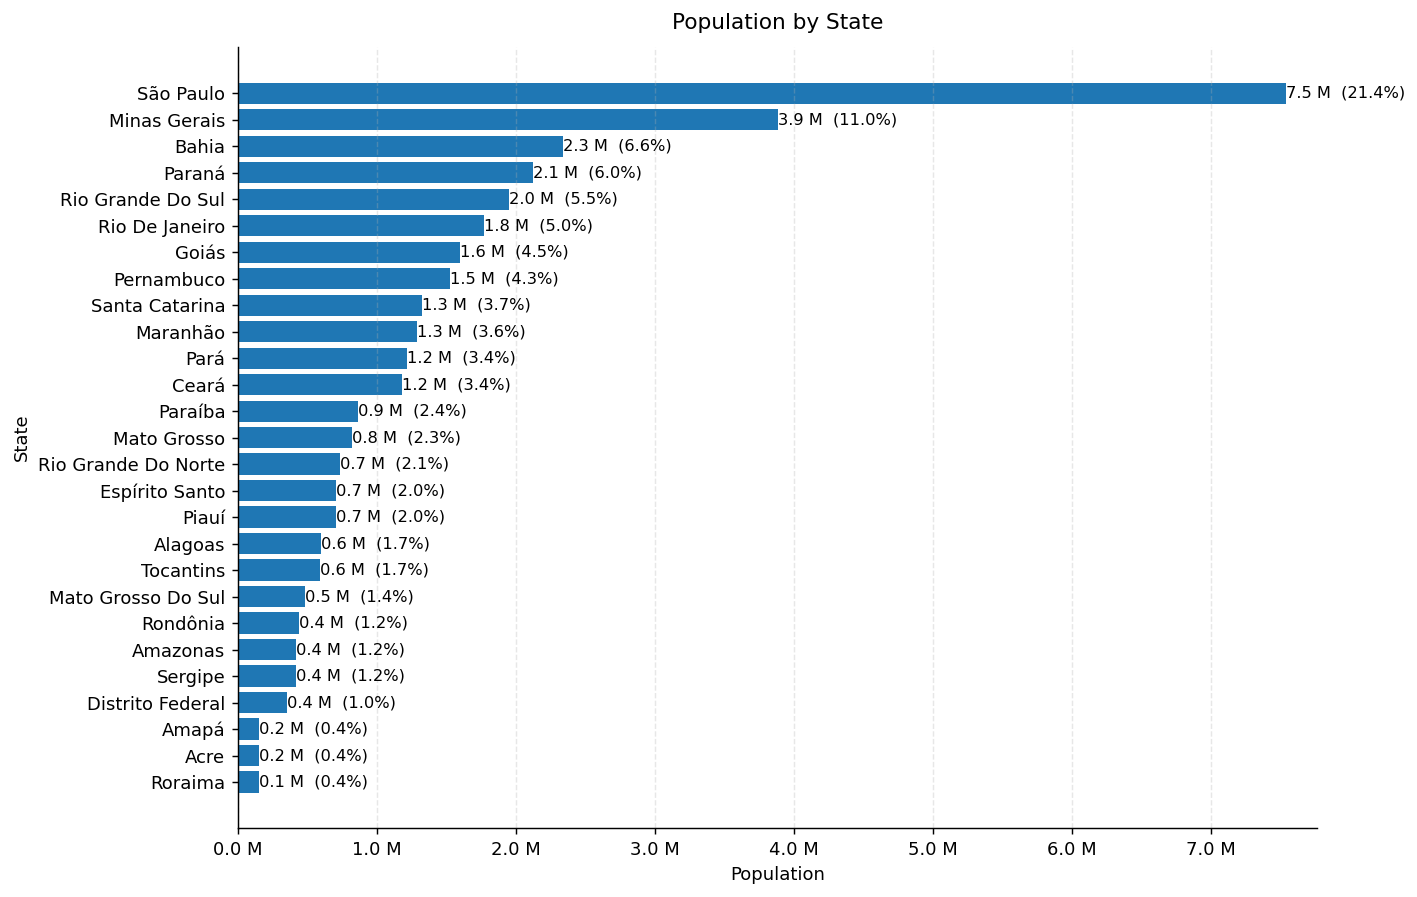

In [14]:
top = pop_named.sort_values()
top_titled = top.copy()
top_titled.index = [str(s).title() for s in top.index]

fig, ax = plt.subplots(figsize=(11,7), dpi=130)
ax.barh(top_titled.index, top_titled.values)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title(f"Population by State", pad=10)
ax.set_xlabel("Population")
ax.set_ylabel("State")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x/1e6:.1f} M"))

total = pop_named.sum()
for i, v in enumerate(top_titled.values):
    ax.text(v, i, f"{v/1e6:.1f} M  ({v/total:.1%})", va="center", ha="left", fontsize=9)

ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.margins(x=0.03)
plt.tight_layout()
plt.show()